In [1]:
# Import relevant libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt  

In [2]:
# Set seed for reproducibility.
np.random.seed(613)

In [3]:
# Load dataset; consider special characters for french language values.
df = pd.read_csv(r'C:\Users\jjsos\Documents\DSI_7\visualization\02_activities\assignments\assignment_3_data\GHG_Data_2010_2022.csv', encoding='latin1')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3381 entries, 0 to 3380
Data columns (total 19 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Year                                               3381 non-null   int64  
 1   Ontario GHG ID                                     3381 non-null   int64  
 2   Facility Owner                                     3381 non-null   object 
 3   Facility Name                                      3381 non-null   object 
 4   Facility City                                      3380 non-null   object 
 5   Facility Primary NAICS Code                        3381 non-null   int64  
 6   Carbon dioxide (CO2) from non-biomass in CO2e (t)  3286 non-null   float64
 7   Carbon dioxide (CO2) from biomass in CO2e (t)      2133 non-null   float64
 8   Methane (CH4) in CO2e (t)                          3369 non-null   float64
 9   Nitrous 

In [4]:
# Keep relevant columns to showcase how emissions evolve across sectors over time.
df_columns = df[[
    'Year',
    'Facility Name',
    'Facility Owner',
    'Facility City',
    'Facility Primary NAICS Code',
    'Total CO2e from all sources in CO2e (t)'
]]

df_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3381 entries, 0 to 3380
Data columns (total 6 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Year                                     3381 non-null   int64 
 1   Facility Name                            3381 non-null   object
 2   Facility Owner                           3381 non-null   object
 3   Facility City                            3380 non-null   object
 4   Facility Primary NAICS Code              3381 non-null   int64 
 5   Total CO2e from all sources in CO2e (t)  3381 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 158.6+ KB


In [5]:
# Inspect for null values.
df_columns.isnull().sum()

Year                                       0
Facility Name                              0
Facility Owner                             0
Facility City                              1
Facility Primary NAICS Code                0
Total CO2e from all sources in CO2e (t)    0
dtype: int64

In [6]:
# Remove null values.
df_columns_prep = df_columns.dropna(subset=['Facility City'])

df_columns_prep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3380 entries, 0 to 3380
Data columns (total 6 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Year                                     3380 non-null   int64 
 1   Facility Name                            3380 non-null   object
 2   Facility Owner                           3380 non-null   object
 3   Facility City                            3380 non-null   object
 4   Facility Primary NAICS Code              3380 non-null   int64 
 5   Total CO2e from all sources in CO2e (t)  3380 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 184.8+ KB


In [7]:
# Define/organize features.
df['Year'] = df['Year'].astype(int)
df['Facility Primary NAICS Code'] = df['Facility Primary NAICS Code'].astype(str)
df['Total CO2e from all sources in CO2e (t)'] = pd.to_numeric(df['Total CO2e from all sources in CO2e (t)'], errors='coerce')

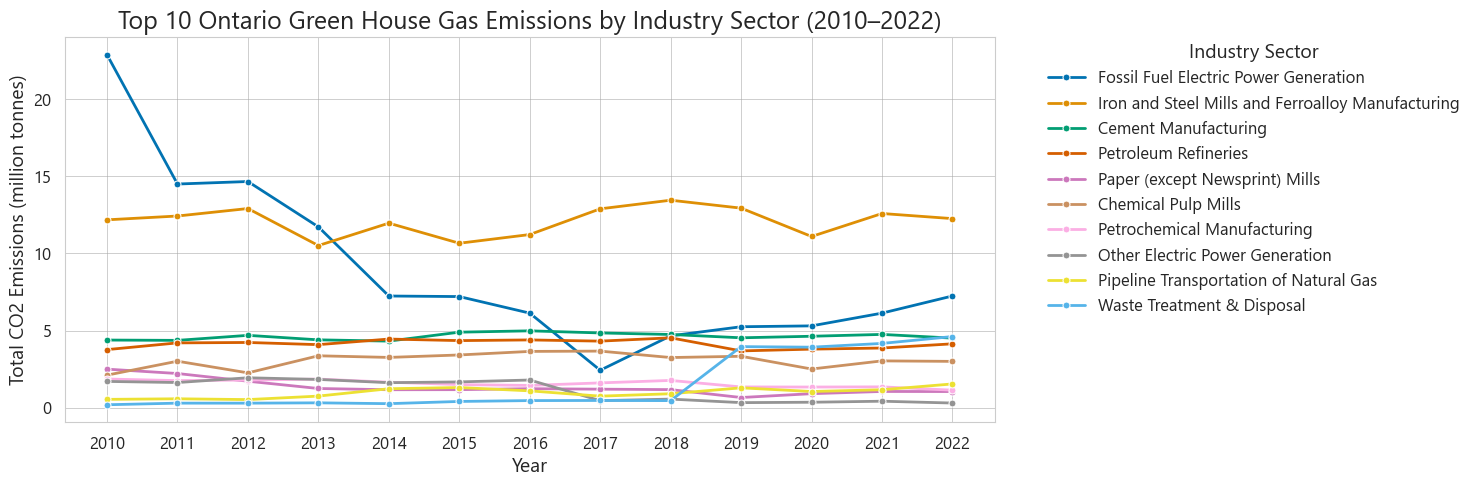

In [8]:
# Pick top 10 NAICS (North American Industry Classification System).
top_naics = (
    df.groupby('Facility Primary NAICS Code', as_index=False)['Total CO2e from all sources in CO2e (t)']
    .sum()
    .sort_values('Total CO2e from all sources in CO2e (t)', ascending=False)
    .head(10)['Facility Primary NAICS Code']
    .tolist()
)

# Copy NAIC list to create label dictionary
df_top = df[df['Facility Primary NAICS Code'].isin(top_naics)].copy()

# Get NAICS labels (North American Industry Classification System (NAICS) Canada 2022 Version 1.0) from here:
# https://www23.statcan.gc.ca/imdb/p3VD.pl?Function=getVD&TVD=1369825 
naics_labels = {
    '221112': 'Fossil Fuel Electric Power Generation',
    '331110': 'Iron and Steel Mills and Ferroalloy Manufacturing',
    '327310': 'Cement Manufacturing',
    '324110': 'Petroleum Refineries',
    '322121': 'Paper (except Newsprint) Mills',
    '322112': 'Chemical Pulp Mills',
    '325110': 'Petrochemical Manufacturing',
    '486210': 'Pipeline Transportation of Natural Gas',
    '562210': 'Waste Treatment & Disposal',
    '221119': 'Other Electric Power Generation'
}

# Replace NAICS Code with Industry Names.
df_top['NAICS_Name'] = (
    df_top['Facility Primary NAICS Code'].astype(str).map(naics_labels)
        .fillna(df_top['Facility Primary NAICS Code'].astype(str))
)

# Create the line plots per industry.
trend = (
    df_top.groupby(['Year', 'NAICS_Name'], as_index=False)['Total CO2e from all sources in CO2e (t)']
          .sum()
          .sort_values(['Year', 'Total CO2e from all sources in CO2e (t)'], ascending=[True, False])
)

# Convert tonnes into millions of tonnes.
trend['Total_CO2e_Mt'] = trend['Total CO2e from all sources in CO2e (t)'] / 1_000_000

# Create font configuration dictionary.
font_settings = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI'], 
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.weight': 'regular',
}

# Set theme.
sns.set_theme(
    style='whitegrid',
    context='notebook',
    rc={
        **font_settings,
        'grid.linewidth': 0.4,
        'grid.color': 'darkgray',
        'axes.edgecolor': '0.8',
        'axes.linewidth': 0.8
    }
)

# Create figure and axes.
plt.figure(figsize=(12, 5))
ax = sns.lineplot(
    data=trend,
    x='Year', 
    y='Total_CO2e_Mt',
    hue='NAICS_Name',
    marker='o', linewidth=2, markersize=5,
    palette=sns.color_palette('colorblind')
)

# Edit titles and create legend.
ax.set_title('Top 10 Ontario Green House Gas Emissions by Industry Sector (2010–2022)')
ax.set_xlabel('Year')
ax.set_ylabel('Total CO2 Emissions (million tonnes)')
ax.set_xticks(sorted(trend['Year'].unique()))
ax.legend(
    title='Industry Sector', 
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0,
    ncol=1,
    frameon=False,
    handlelength=2.2
    )

# Print visualization.
plt.show()